<a href="https://colab.research.google.com/github/lilmiztee04/Uow_Data_Engineering/blob/main/newSMEModel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
#load file and rename and check attributes
import pandas as pd
SME = pd.read_csv('/content/social_media_engagement1.csv')
display(SME.head())

,post_id,platform,post_type,post_time,likes,comments,shares,post_day,sentiment_score
0,1,Facebook,image,8/17/2023 14:45,2121,474,628,Thursday,positive
1,2,Facebook,carousel,5/14/2023 0:45,3660,432,694,Sunday,neutral
2,3,Instagram,poll,2/21/2023 16:15,4955,408,688,Tuesday,negative
3,4,Twitter,image,11/16/2023 0:45,1183,90,187,Thursday,negative
4,5,Twitter,video,5/23/2023 0:30,3499,247,286,Tuesday,positive


In [3]:
#check if there are missing data and if dataset needs to be cleaned up
SME.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   post_id          100 non-null    int64 
 1   platform         100 non-null    object
 2   post_type        100 non-null    object
 3   post_time        100 non-null    object
 4   likes            100 non-null    int64 
 5   comments         100 non-null    int64 
 6   shares           100 non-null    int64 
 7   post_day         100 non-null    object
 8   sentiment_score  100 non-null    object
dtypes: int64(4), object(5)
memory usage: 7.2+ KB


In [4]:
#remove unnecessary attributes, twitter isnt needed as im focusing on meta platform
SME = SME[SME['platform'] != 'Twitter']
display(SME.head())

,post_id,platform,post_type,post_time,likes,comments,shares,post_day,sentiment_score
0,1,Facebook,image,8/17/2023 14:45,2121,474,628,Thursday,positive
1,2,Facebook,carousel,5/14/2023 0:45,3660,432,694,Sunday,neutral
2,3,Instagram,poll,2/21/2023 16:15,4955,408,688,Tuesday,negative
5,6,Instagram,carousel,5/5/2023 20:00,256,186,211,Friday,neutral
6,7,Instagram,image,2/26/2023 11:45,1982,30,906,Sunday,positive


In [5]:
import random

# Define a list of content themes based on user's input
content_themes = [
    'Informational/Educational',
    'Promotional (Product Specific)',
    'UGC (User Generated Content)',
    'Lifestyle/Brand Storytelling',
    'Trend-based'
]

# Randomly assign a content theme to each row in the SME DataFrame
SME['content_theme'] = [random.choice(content_themes) for _ in range(len(SME))]

display(SME.head())

,post_id,platform,post_type,post_time,likes,comments,shares,post_day,sentiment_score,content_theme
0,1,Facebook,image,8/17/2023 14:45,2121,474,628,Thursday,positive,UGC (User Generated Content)
1,2,Facebook,carousel,5/14/2023 0:45,3660,432,694,Sunday,neutral,Trend-based
2,3,Instagram,poll,2/21/2023 16:15,4955,408,688,Tuesday,negative,Trend-based
5,6,Instagram,carousel,5/5/2023 20:00,256,186,211,Friday,neutral,Informational/Educational
6,7,Instagram,image,2/26/2023 11:45,1982,30,906,Sunday,positive,Informational/Educational


In [6]:
#create a new table for futher analytic analysis on when iis the best time to post advertisement
engagement_metrics = SME[['post_day','platform', 'post_time', 'likes', 'comments', 'shares']].copy()
display(engagement_metrics.head())

,post_day,platform,post_time,likes,comments,shares
0,Thursday,Facebook,8/17/2023 14:45,2121,474,628
1,Sunday,Facebook,5/14/2023 0:45,3660,432,694
2,Tuesday,Instagram,2/21/2023 16:15,4955,408,688
5,Friday,Instagram,5/5/2023 20:00,256,186,211
6,Sunday,Instagram,2/26/2023 11:45,1982,30,906


In [7]:
#new tabel created
postAna = engagement_metrics
display(postAna.head())

,post_day,platform,post_time,likes,comments,shares
0,Thursday,Facebook,8/17/2023 14:45,2121,474,628
1,Sunday,Facebook,5/14/2023 0:45,3660,432,694
2,Tuesday,Instagram,2/21/2023 16:15,4955,408,688
5,Friday,Instagram,5/5/2023 20:00,256,186,211
6,Sunday,Instagram,2/26/2023 11:45,1982,30,906


In [8]:
postAna.info()

<class 'pandas.core.frame.DataFrame'>
Index: 68 entries, 0 to 99
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   post_day   68 non-null     object
 1   platform   68 non-null     object
 2   post_time  68 non-null     object
 3   likes      68 non-null     int64 
 4   comments   68 non-null     int64 
 5   shares     68 non-null     int64 
dtypes: int64(3), object(3)
memory usage: 3.7+ KB


In [9]:
SME = SME.drop(columns=['post_day', 'post_time'])
display(SME.head())

,post_id,platform,post_type,likes,comments,shares,sentiment_score,content_theme
0,1,Facebook,image,2121,474,628,positive,UGC (User Generated Content)
1,2,Facebook,carousel,3660,432,694,neutral,Trend-based
2,3,Instagram,poll,4955,408,688,negative,Trend-based
5,6,Instagram,carousel,256,186,211,neutral,Informational/Educational
6,7,Instagram,image,1982,30,906,positive,Informational/Educational


In [10]:
SME.to_csv('SMEprocessed.csv', index=False)
print('SME DataFrame saved to SMEprocessed.csv')

SME DataFrame saved to SMEprocessed.csv


In [11]:
postAna.to_csv('post_analysis_data.csv', index=False)
print('postAna DataFrame saved to post_analysis_data.csv')

postAna DataFrame saved to post_analysis_data.csv


In [12]:
#creating engagement score calculations for ANOVA
SME = pd.read_csv('SMEprocessed.csv')
SME['engagement'] = SME['likes'] + SME['comments'] + SME['shares']

In [13]:
#weighted
SME['weighted_engagement'] = (
    SME['likes'] +
    (2 * SME['comments']) +
    (3 * SME['shares'])
)

In [14]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
SME['engagement_rate'] = scaler.fit_transform(
    SME[['weighted_engagement']]
)

In [15]:
sentiment_map = {'positive': 1, 'neutral': 0, 'negative': -1}
SME['sentiment_score'] = SME['sentiment_score'].map(sentiment_map)

SME['sentiment_adjusted_engagement'] = (
    SME['weighted_engagement'] * SME['sentiment_score']
)

In [16]:
SME.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68 entries, 0 to 67
Data columns (total 12 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   post_id                        68 non-null     int64  
 1   platform                       68 non-null     object 
 2   post_type                      68 non-null     object 
 3   likes                          68 non-null     int64  
 4   comments                       68 non-null     int64  
 5   shares                         68 non-null     int64  
 6   sentiment_score                68 non-null     int64  
 7   content_theme                  68 non-null     object 
 8   engagement                     68 non-null     int64  
 9   weighted_engagement            68 non-null     int64  
 10  engagement_rate                68 non-null     float64
 11  sentiment_adjusted_engagement  68 non-null     int64  
dtypes: float64(1), int64(8), object(3)
memory usage: 6.5

In [17]:
print(SME.isna().sum())
SME = SME.dropna(subset=['likes', 'comments', 'shares', 'sentiment_score', 'engagement_rate'])
# or fill with zeros/mean if appropriate

post_id                          0
platform                         0
post_type                        0
likes                            0
comments                         0
shares                           0
sentiment_score                  0
content_theme                    0
engagement                       0
weighted_engagement              0
engagement_rate                  0
sentiment_adjusted_engagement    0
dtype: int64


In [18]:
SME.head()

,post_id,platform,post_type,likes,comments,shares,sentiment_score,content_theme,engagement,weighted_engagement,engagement_rate,sentiment_adjusted_engagement
0,1,Facebook,image,2121,474,628,1,UGC (User Generated Content),3223,4953,0.515247,4953
1,2,Facebook,carousel,3660,432,694,0,Trend-based,4786,6606,0.723538,0
2,3,Instagram,poll,4955,408,688,-1,Trend-based,6051,7835,0.878402,-7835
3,6,Instagram,carousel,256,186,211,0,Informational/Educational,653,1261,0.050025,0
4,7,Instagram,image,1982,30,906,1,Informational/Educational,2918,4760,0.490927,4760


In [19]:
SME.to_csv('SMEengagement.csv', index=False)
print('SME DataFrame saved to SMEengagement.csv')

SME DataFrame saved to SMEengagement.csv


In [20]:
import pandas as pd
import statsmodels.api as sm

# Reload SME to ensure original categorical columns are present
SME = pd.read_csv('SMEengagement.csv')

# Encode categorical variables
SME = pd.get_dummies(SME, columns=['post_type', 'content_theme'], drop_first=True)

# Define independent variables (exclude target & derived columns)
X = SME[['likes', 'comments', 'shares', 'sentiment_score'] +
        [col for col in SME.columns if 'post_type_' in col or 'content_theme_' in col]]

# Convert boolean columns in X to integer (0s and 1s) to avoid ValueError in statsmodels
for col in X.columns:
    if X[col].dtype == 'bool':
        X[col] = X[col].astype(int)

# Define target variable
y = SME['engagement_rate']

# Add constant term for regression intercept
X = sm.add_constant(X)

# Fit OLS regression model
model = sm.OLS(y, X).fit()

# Show summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:        engagement_rate   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 3.057e+30
Date:                Tue, 24 Mar 2026   Prob (F-statistic):               0.00
Time:                        09:37:42   Log-Likelihood:                 2331.9
No. Observations:                  68   AIC:                            -4638.
Df Residuals:                      55   BIC:                            -4609.
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                                                   coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------

/tmp/ipykernel_5550/2492910779.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = X[col].astype(int)
/tmp/ipykernel_5550/2492910779.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = X[col].astype(int)
/tmp/ipykernel_5550/2492910779.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexin

In [21]:
X = X.drop(columns=['shares', 'comments','shares','const'])  # example
model = sm.OLS(y, X).fit()

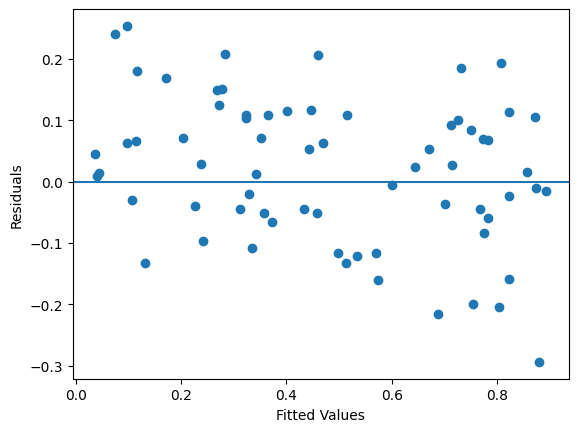

In [22]:
import matplotlib.pyplot as plt

residuals = model.resid

plt.scatter(model.fittedvalues, residuals)
plt.axhline(y=0)
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.show()

<Axes: ylabel='Count'>

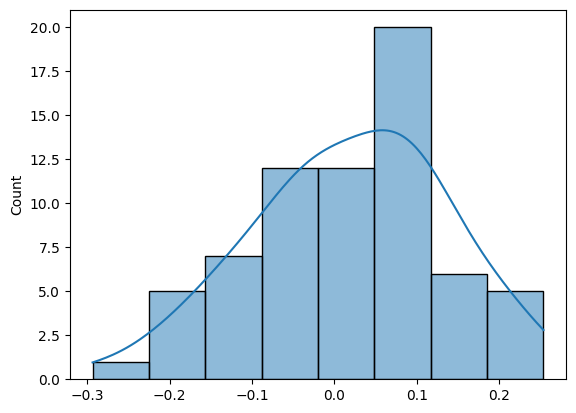

In [23]:
import seaborn as sns

sns.histplot(residuals, kde=True)

In [24]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif = pd.DataFrame()
vif["Variable"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif)

                                       Variable       VIF
0                                         likes  4.347768
1                               sentiment_score  1.095131
2                               post_type_image  1.478273
3                                post_type_poll  1.642460
4                                post_type_text  1.510846
5                               post_type_video  2.414985
6    content_theme_Lifestyle/Brand Storytelling  1.767390
7  content_theme_Promotional (Product Specific)  2.010943
8                     content_theme_Trend-based  1.816130
9    content_theme_UGC (User Generated Content)  1.553489


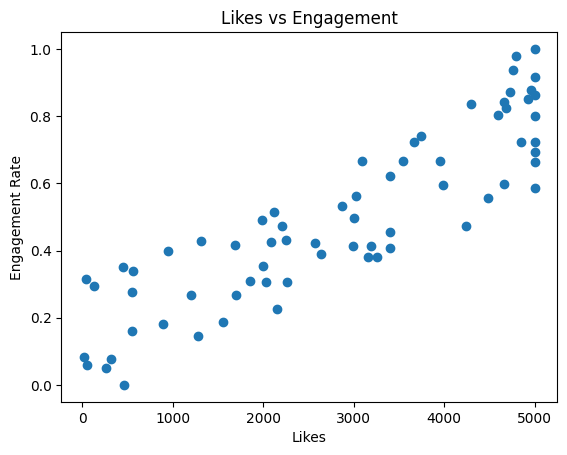

In [25]:
import matplotlib.pyplot as plt

plt.scatter(SME['likes'], y)
plt.xlabel("Likes")
plt.ylabel("Engagement Rate")
plt.title("Likes vs Engagement")
plt.show()

In [26]:
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import pandas as pd

# Reload SME to ensure original categorical columns are present for plotting
SME = pd.read_csv('SMEengagement.csv')

# Create subplots layout
fig = make_subplots(
    rows=3, cols=3,
    subplot_titles=(
        "Engagement Rate Distribution",
        "Likes vs Engagement Rate",
        "Post Type Performance",
        "Content Theme Performance",
        "Likes vs Engagement Rate by Post Type"
    )
)

# 1. Engagement Rate Distribution
fig.add_trace(
    go.Histogram(x=SME['engagement_rate'], name="Engagement Rate"),
    row=1, col=1
)

# 2. Likes vs Engagement
fig.add_trace(
    go.Scatter(
        x=SME['likes'],
        y=SME['engagement_rate'],
        mode='markers',
        name="Likes vs Engagement"
    ),
    row=1, col=2
)

# 3. Post Type Performance
post_type_avg = SME.groupby('post_type')['engagement_rate'].mean().reset_index()

fig.add_trace(
    go.Bar(
        x=post_type_avg['post_type'],
        y=post_type_avg['engagement_rate'],
        name="Post Type"
    ),
    row=2, col=1
)

# 4. Content Theme Performance
theme_avg = SME.groupby('content_theme')['engagement_rate'].mean().reset_index()

fig.add_trace(
    go.Bar(
        x=theme_avg['content_theme'],
        y=theme_avg['engagement_rate'],
        name="Content Theme"
    ),
    row=2, col=2
)

# 5. Likes vs Engagement Rate by Post Type (using px.scatter and then adding trace)
px_fig = px.scatter(SME,
           x='likes',
           y='engagement_rate',
           color='post_type',
           hover_data=['content_theme'])

for trace in px_fig['data']:
    fig.add_trace(trace, row=3, col=1)

# Layout adjustments
fig.update_layout(
    height=1200, # Increased height to accommodate the new row
    width=1200,  # Increased width for better visualization
    title_text="Social Media Engagement Dashboard",
    showlegend=True # Show legend for the new scatter plot colors
)

fig.show()

In [27]:
print("Average Engagement Rate:", SME['engagement_rate'].mean())
print("Best Post Type:", post_type_avg.sort_values(by='engagement_rate', ascending=False).iloc[0])

Average Engagement Rate: 0.5013601458728653
Best Post Type: post_type              poll
engagement_rate    0.637447
Name: 2, dtype: object


In [28]:
SME['predicted_engagement'] = model.predict(X)
SME['residuals'] = SME['engagement_rate'] - SME['predicted_engagement']

In [29]:
SME.to_csv("enhanced_SME.csv", index=False)